In [1]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [2]:
VOWELS = "aeıioöuü"
FRONT_VOWELS = "eiöü"
BACK_VOWELS = "aıou"

In [3]:
df = pd.read_csv("final_dataset_lowercase.csv")

In [4]:

X = df["kelime"]   # sütun adını kontrol et
y = df["label"]  # label sütunun

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_manual = vectorizer.transform(X_test)

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
def has_turkish_chars(word):
    return int(any(c in "çğıöşü" for c in word))

In [7]:
def word_length(word):
    return len(word)

In [8]:
def has_double_consonant(word):
    for i in range(len(word) - 1):
        if word[i] == word[i+1] and word[i] not in VOWELS:
            return 1
    return 0

In [9]:
def major_vowel_harmony(word):
    vowels = [c for c in word if c in VOWELS]
    
    if not vowels:
        return 0
    
    first = vowels[0]
    
    if first in FRONT_VOWELS:
        return int(all(v in FRONT_VOWELS for v in vowels))
    else:
        return int(all(v in BACK_VOWELS for v in vowels))

In [10]:
def minor_vowel_harmony(word):
    vowels = [c for c in word if c in VOWELS]
    
    if len(vowels) < 2:
        return 1
    
    for i in range(len(vowels) - 1):
        if vowels[i] in "aı" and vowels[i+1] not in "aı":
            return 0
        if vowels[i] in "ei" and vowels[i+1] not in "ei":
            return 0
    
    return 1

In [11]:
def vowel_ratio(word):
    if len(word) == 0:
        return 0
    vowel_count = sum(1 for c in word if c in VOWELS)
    return vowel_count / len(word)

In [12]:
TURKISH_SUFFIXES = [
    "lık", "lik", "luk", "lük",
    "cı", "ci", "cu", "cü",
    "daş", "taş",
    "lar", "ler"
]

def has_turkish_suffix(word):
    return int(any(word.endswith(suffix) for suffix in TURKISH_SUFFIXES))

In [13]:
def extract_features(word):
    word = word.lower()
    
    return [
        has_turkish_chars(word),
        word_length(word),
        has_double_consonant(word),
        major_vowel_harmony(word),
        minor_vowel_harmony(word),
        vowel_ratio(word),
        has_turkish_suffix(word)
    ]

In [14]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2,4),
    min_df=2
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [15]:
X_train_custom = [extract_features(word) for word in X_train]
X_test_custom = [extract_features(word) for word in X_test]

X_train_manual = csr_matrix(X_train_custom)
X_test_manual = csr_matrix(X_test_custom)

X_train_final = hstack([X_train_tfidf, X_train_manual])
X_test_final = hstack([X_test_tfidf, X_test_manual])

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


✅ Modelin Doğruluk Oranı (Accuracy): %85.15

📊 Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1031
           1       0.82      0.80      0.81       680

    accuracy                           0.85      1711
   macro avg       0.85      0.84      0.84      1711
weighted avg       0.85      0.85      0.85      1711



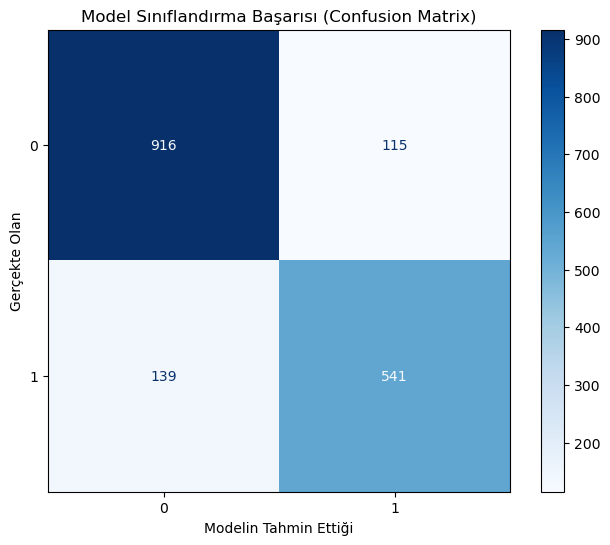

In [17]:
y_pred = model.predict(X_test_final)

# 2. Accuracy (Doğruluk) Oranını Hesapla
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Modelin Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}\n")

# 3. Detaylı Sınıflandırma Raporu (Hangi sınıfta daha başarılı?)
print("📊 Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred))

# 4. Karmaşıklık Matrisi (Confusion Matrix) Grafiği Oluştur
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Grafiği çizdir
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Model Sınıflandırma Başarısı (Confusion Matrix)")
plt.xlabel("Modelin Tahmin Ettiği")
plt.ylabel("Gerçekte Olan")
plt.show()

In [18]:

# DataFrame'e dökelim
results = pd.DataFrame({
    "word": X_test,
    "true": y_test,
    "pred": y_pred
})

# Sadece yanlış tahminler
wrong = results[results["true"] != results["pred"]]

print(f"Toplam yanlış tahmin: {len(wrong)}\n")

# İlk 20 hatayı göster
print(wrong.head(20))

Toplam yanlış tahmin: 254

            word  true  pred
1550        ikiz     1     0
2716       üstün     1     0
5426  demirhindi     0     1
1699      kungfu     0     1
2884      barbol     1     0
6223     oynamak     1     0
3708      ilkoca     1     0
5746    arademir     1     0
5612    alkaevli     1     0
2663        eyiz     1     0
8521      devrim     1     0
3094          ev     1     0
1737     mengene     0     1
6797        kamu     1     0
7603       bacak     1     0
2484    selsebil     0     1
6768      katran     1     0
17          diri     1     0
7347   bahsetmek     1     0
3282     kırmızı     0     1


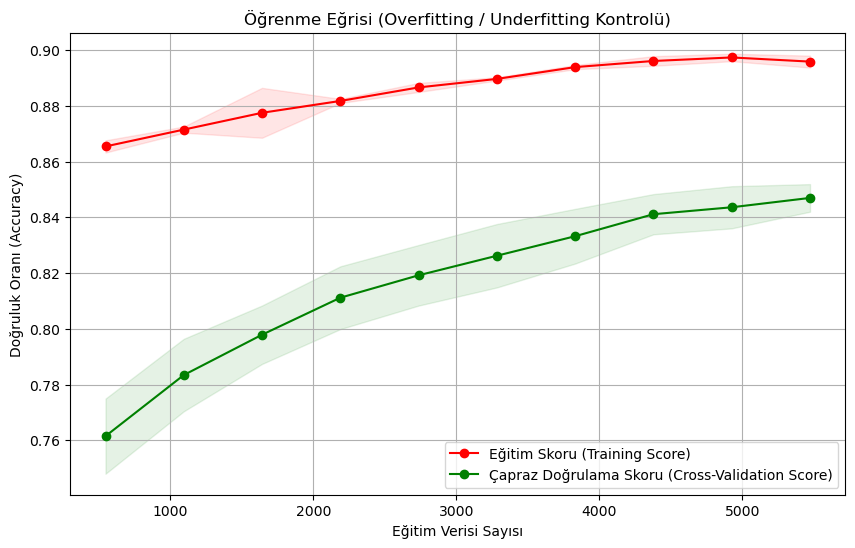

In [19]:


# Öğrenme Eğrisi (Learning Curve) hesaplama
# cv=5 demek veriyi 5 parçaya bölüp çapraz doğrulama yapacak demektir.
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_final, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Skorların ortalamasını ve standart sapmasını (hata payını) hesapla
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Grafiği Çizdirme
plt.figure(figsize=(10, 6))
plt.title("Öğrenme Eğrisi (Overfitting / Underfitting Kontrolü)")
plt.xlabel("Eğitim Verisi Sayısı")
plt.ylabel("Doğruluk Oranı (Accuracy)")

# Standart sapma alanlarını boya (Modelin kararlılığını gösterir)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="red")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="green")

# Ana çizgileri çiz
plt.plot(train_sizes, train_scores_mean, 'o-', color="red", label="Eğitim Skoru (Training Score)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="green", label="Çapraz Doğrulama Skoru (Cross-Validation Score)")

plt.legend(loc="lower right")
plt.grid(True)
plt.show()